<a href="https://colab.research.google.com/github/muberragul/Fraud-Detection-and-Finance-Chatbot/blob/main/Finance_ChatBot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Auto Loan Chatbot Demo Using Llama 3

# Görev: Araç Finansmanı Chatbot Tasarım  

**Senaryo Açıklaması**: Müşteriler mobil uygulama tarafından sunulan sohbet robotu
yardımıyla bankamızda taşıt finansmanı ön başvurusu yapacaktır. Taşıt finansmanı yeni
veya 2. (ikinci) el araçlar için yapılacaktır. Müşteriden alınması gereken bilgiler ve bu
bilgilerin sağlaması gereken kriterler araç finansmanı türüne göre aşağıdaki gibidir:

Yeni Taşıt Finansmanı için:
- Araç proforma fatura değeri (7M üzeri araçlar için başvuru yapılamaz)
- Araç modeli (Ticari Modeller için başvuru yapılamaz)
- Kefil TCKN (Araç Fiyatı 5M ve üzeri olan başvurular için gereklidir. Diğer durumlar
kefil gerektirmez)
- İstenen finansman tutarı (Araç Fiyatının en fazla %60’u talep edilebilir)

İkinci El Finansmanı için:
- Araç kasko değeri
- Araç Yaşı (5 yaş üstü araçlar için başvuru oluşturulamaz)
- İstenen finansman tutarı (Araç Kasko değerinin en fazla %40’ı veya üst barem olan
3M turarını aşamaz)
- Satıcı T.C. kimlik numarası (Bu alan zorunlu değildir. Boş bırakılabilir.)

Bu kapsamda chatbot’umuz müşterinin araç finansmanı türünü (yeni veya ikinci el)
netleştirecek, sonrasında da araç finansmanı türüne göre alması gereken bilgileri
toplayacak ve bu bilgilerin sağlaması gereken koşulları kontrol edecektir. Tasarlanan
chatbot müşterilerin kişisel bilgilerini banka dışına çıkarmadan çalışmalıdır. Süreci
başarıyla ilerleyen müşteriler için toplanan bilgiler son kez müşteriye teyit ettirilecektir.
Müşteri bu bilgileri güncelleyebilecektir. Sonrasında ise chatbot tarafından veri tabanına
ön başvuru kaydı atılması sağlanacaktır.  

Ayrıca kurumda araç finansmanı ile ilgili sıkça sorulan sorular derlenip süreci anlatan bir
doküman haline getirilmiştir. Chatbot’un bu dokümanı kullanarak müşterinin araç
finansmanıyla ilgili olası sorularını yanıtlayabilmesi de beklenmektedir.

Taşıt finansmanı ön başvurusunu başarıyla yapan müşteriler için çapraz satış politikası
kapsamında HGS ürünü isteyip istemediği de sorulacaktır.

Yerel sunucularımız üzerinde kurulu 2 adet her biri 48 GB olacak şekilde toplam 96 GB
GPU kaynağımız mevcuttur.  

Bu chatbot’u bulutta yer alan veya yerel’e indirilen açık kaynaklı büyük dil modelleriyle
geliştirebilirsiniz.

# 1) ChatBot Geliştirme Aşamaları

1. LLM Araştırması:
    *   Dil desteği olan (Türkçe ile iyi çalışan)
    *   Hızlı
    *   Open source
    *   Instruction model
    *   Boyut sınırına uygun (2x48GB)
    *   JSON obje ayıklayabilen
    *   Functioncall yapabilen modeller incelenir.
2. Workflow çıkartılır.
3. Mimari Tasarımı:
    *   Kullanılmak istenen modelin bulutta mı yerelde mi kurulacağı netleştirilir.
    *   Prompt-engineering ile function calling stratejisi (JSON parsing) belirlenir.
    *   Validasyon için deterministik kural katmanı tasarlanır.   
5. Chatbot Geliştirme:
    *   Model ayağa kaldırılır.
    *   Modelin conversation metrikleri (system prompt, conversation history vb.) kurgulanır.
    *   Çağrılacak fonksiyonlar implemente edilir.
    *   txt -> JSON format dönüşümü için parser implemente edilir.
    *   Kullanıcıyla etkileşime girilebilecek şekilde geliştirme yapılır.
6. Test (Demo)

# 2) Sistem Mimarisi

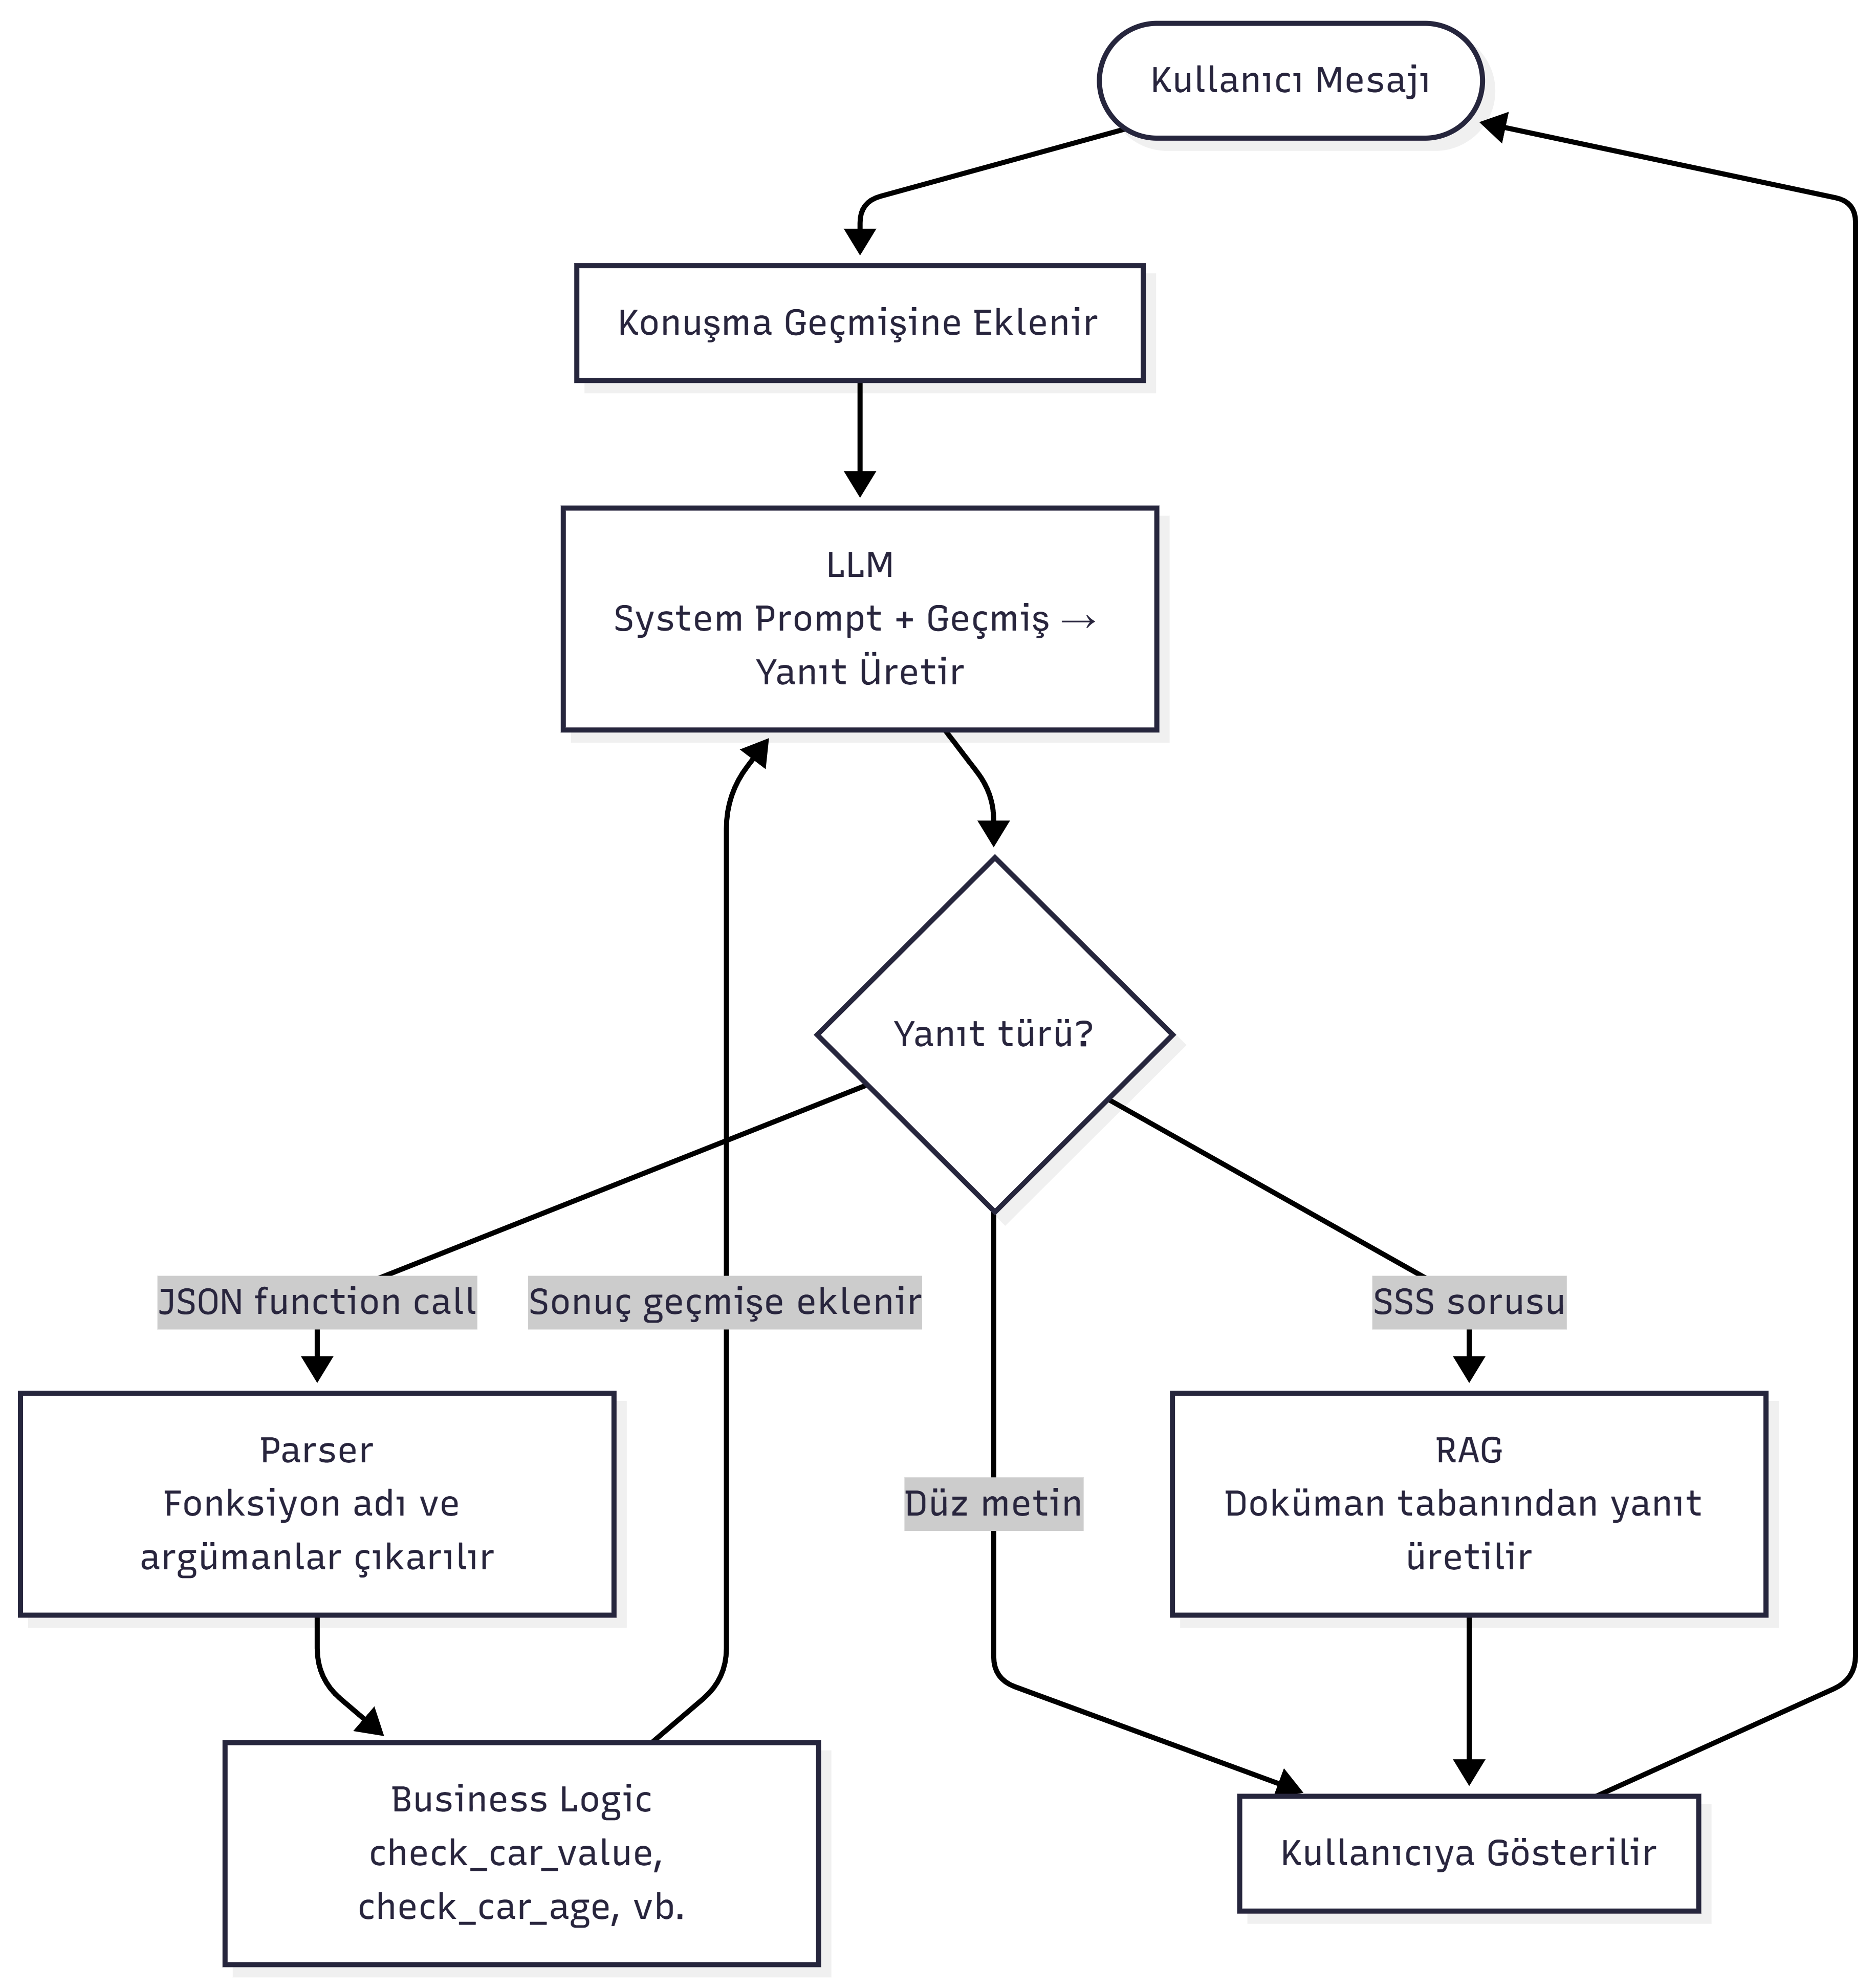

Chatbot kullanıcıyla etkileşime girer, bilgi toplar ve ardından system_prompt'a göre JSON formatında bir function_call oluşturur. Bu function_call daha sonra parse edilir ve belirli kontrolleri (ör. check_car_value, check_car_age) gerçekleştirmesi için bir Python fonksiyonu (handle_function_call) tarafından çalıştırılır. Bu fonksiyon çağrısının sonucu daha sonra LLM ile yapılan sohbete geri beslenir ve bir sonraki yanıtını yönlendirir.

Sistem güvenliği ve maliyet nedeniyle modelin on-premise kurulmasına karar verildi. Verinin lokal ortamdan çıkmaması regülasyonlar için önemlidir. API ücreti ödemek yerine mevcut GPU lokal'de modelin çalıştırılması için yeterlidir.


# 3) Workflow

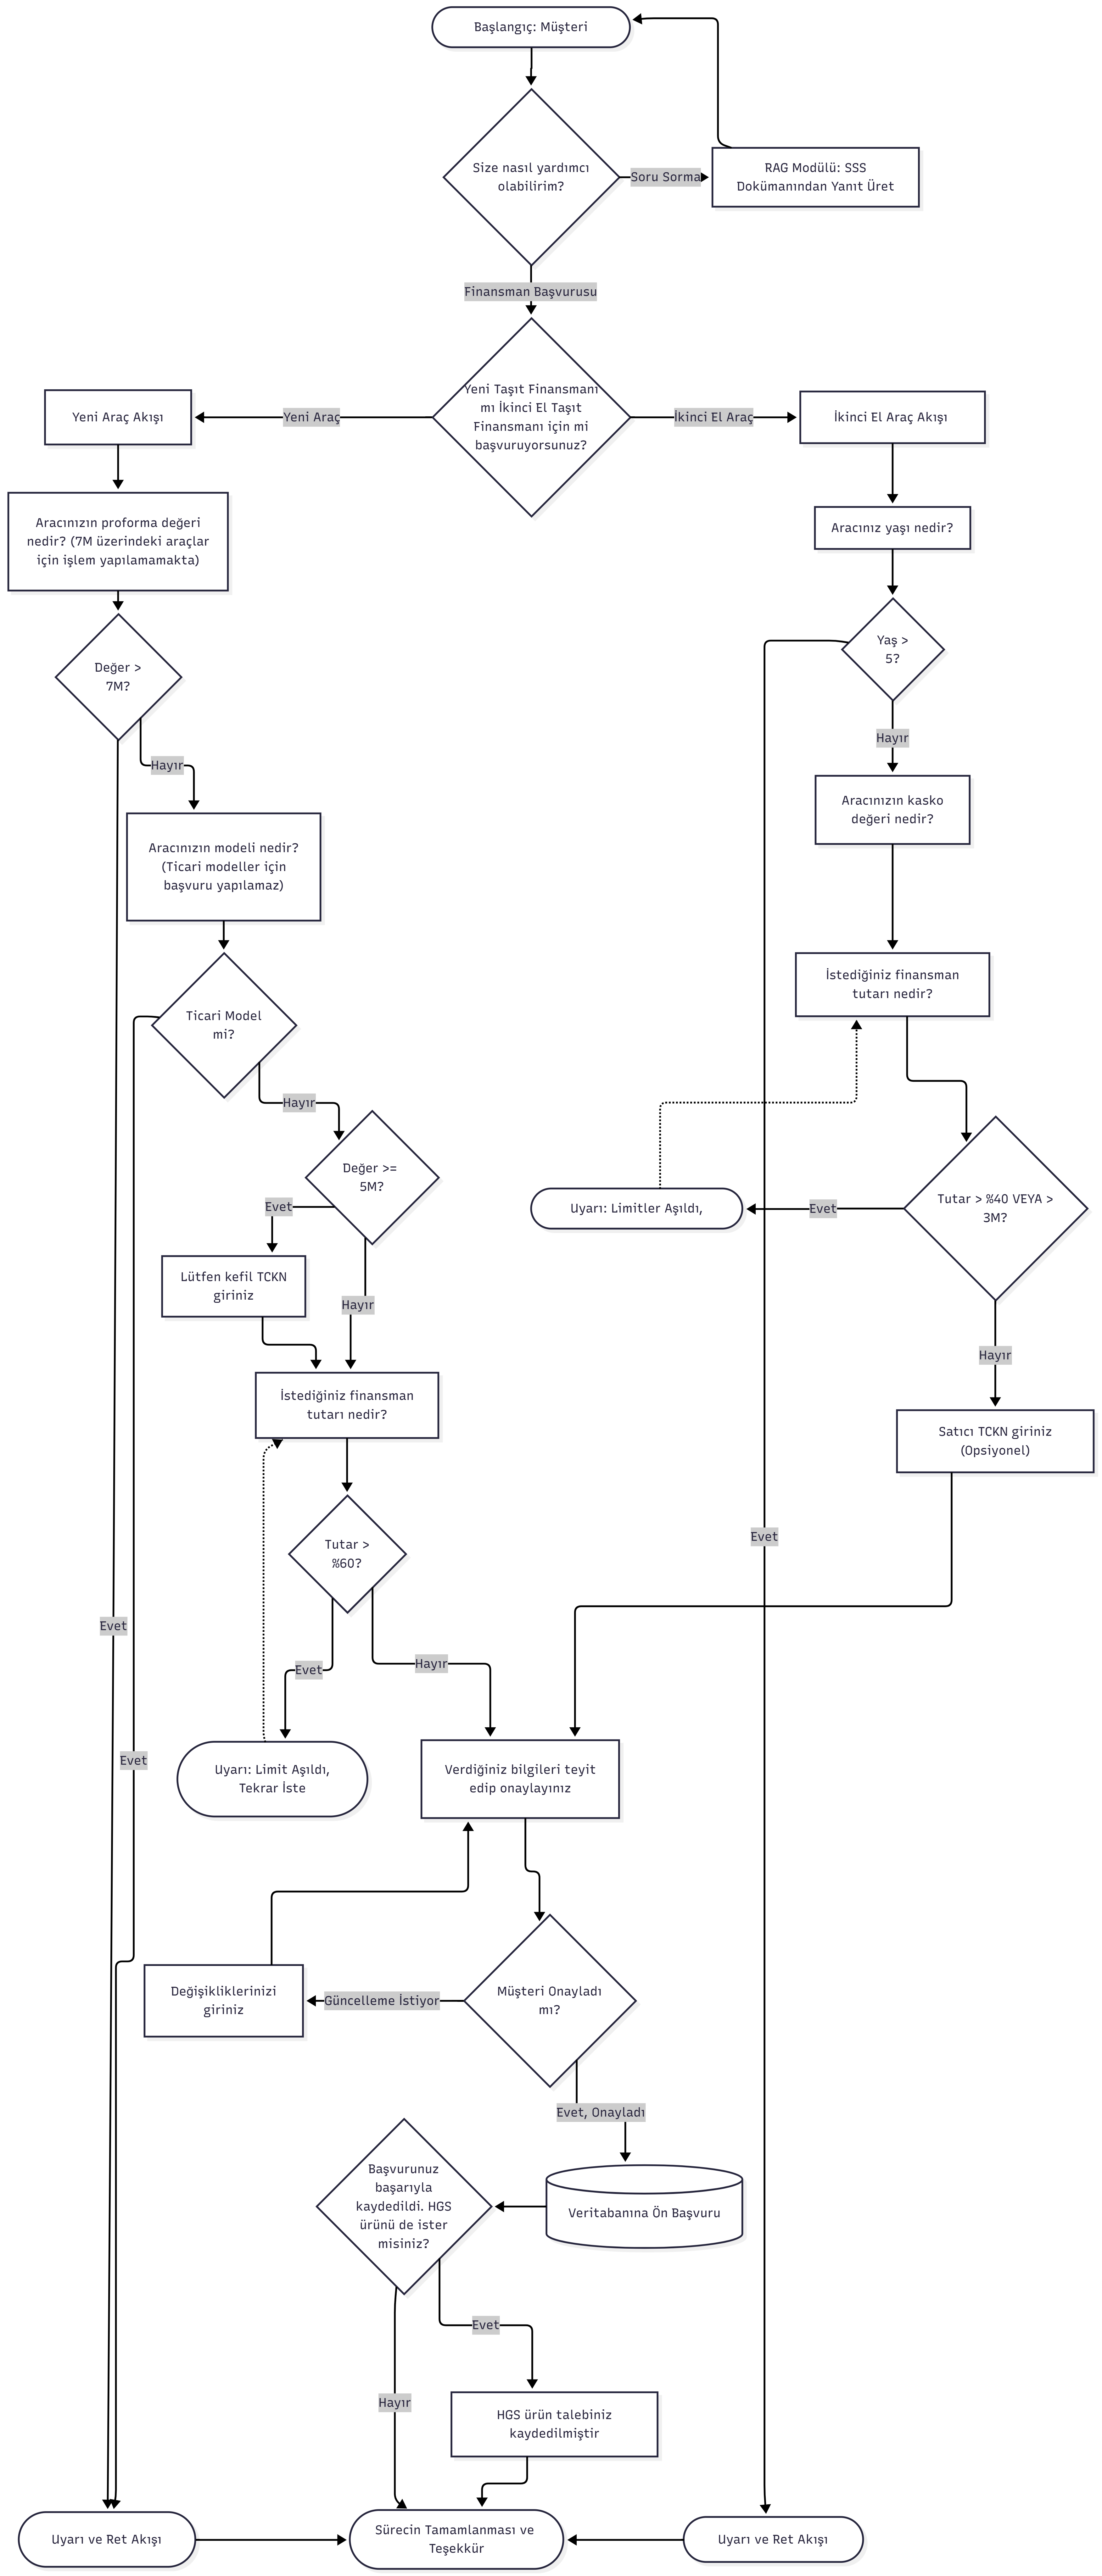

# 4) Agentic Sistem Tasarımı Değerlendirmesi

Sistem agentic olsaydı LLM sonraki adımda ne yapacağına kendisi karar verirdi. Şu anda promptta bu aşamalar detaylı verilmek durumunda kalınıyor. Agentic olsa lineer bir ilerleyiş yerine duruma göre adım seçilebilirdi. Paralel agent'lar çalışabilirdi. Sistem daha komplikeleşirdi.
Küçük bir demo için trade-off yapıldığında tercih edilmeyebilirdi.

# 5) Sistem Güvenliği

YZ Asistanları için güvenlik katmanı neden gereklidir? Tasarlanan sistem için
güvenlik ihtiyaçları nelerdir, nasıl kurguladınız?

LLM'ler deterministik çalışmadığı için öngörülemez çıktılar verebilirler. Bu durum prompt injection, data leakage ve halüsinasyon yaşanmasına sebep olabilir. Bankacılık regülasyonlarına ve risk yönetimine uygun olması için güvenlik katmanlarına ihtiyaç duyulur.

Bu demo için system_prompt'ta alınacak input ve verilebilecek response'lar tip, içerik, format olarak sınırlandırıldı. Data leakage'ın önüne geçmek için on-premise bir model ile çalışıldı, bilgiler regülasyona uygun olarak buluta gönderilmedi. Halüsinasyon için model test edilirken zorlandı ama demo ölçülerinde başarılı sonuç verdi.

# 6) Dil Modeli Seçimi

Dil modeli seçilirken

*   Dil desteği (benchmark yapılabilir),
*   Çalışma hızı,
*   Bulutta/yerelde çalışabilmesi,
*   Open source olması,
*   Instruction model olması,
*   JSON obje ayıklayabilmesi (native JSON modu olabilir),
*   Mümkünse fintech terimlerine hakim/finetune edilmiş olması
kriterleri göz önünde bulundurulur.

Bu kriterlere göre demo için ilk olarak **Qwen 2.5/3** Instruction modeli tercih edilmiştir. Bu model literatür araştırmasına göre Türkçe ve finans verisiyle başarılı çalışmaktadır. JSON mode ve functioncalling özelliklerine sahiptir. Inference iyileştirmesi yapılmak istenirse vLLM entegrasyonu ile yüksek throughput elde edilebilir. 7B parametre ile vLLM ve quantization'a ihtiyaç duyması, yavaş yüklenmesi gibi nedenlerle daha sonra **Qwen/Qwen2.5-1.5B-Instruct** ve **Qwen/Qwen2.5-0.5B-Instruct** modelleri de denenmiştir. Hız ve Türkçe uyumluluk nedeniyle **Llama 3 Instruct** modeli tercih edilmiştir.

Bir gerçek hayat projesinde alternatifleri de belirlenip benchmark analizi yapılırdı.



# 7) Inference İyileştirmesi

Chatbot’ta inference maliyetini düşürmek için

  *   Continuous batching (vLLM yardımıyla),
  *   Quantization,
  *   Kompakt kurgu/kısa system prompt'u tercih etme (az token harcama),
  *   Semantic caching (SSS'de sık sorulanların önbelleğe alınması)
çözümleri uygulanabilir.

# 8) İyileştirme Önerileri

Chatbot üzerinden yapılan başvuru sürecinde iyileştirme için

  *   Input type sınırlama ile istenen veri tipi dışında girdi kabul etmeme,
  *   OCR desteği ile kasko gibi bir belge taratılarak bazı verileri otomatik toplama,
  *   Sentiment analizine göre ret döngüsünde kalan bir kullanıcıyı canlı desteğe yönlendirme
uygulamlarının yapılması önerilebilir.

# 9) ChatBot Demosu

In [ ]:
%%bash
pip install transformers accelerate bitsandbytes -q
pip install -U bitsandbytes>=0.46.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 13.8 MB/s eta 0:00:00


In [ ]:
import os
# Kütüphane kurulumundan sonra oturumu otomatik yeniden başlatmak için:
os.kill(os.getpid(), 9)

In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
import torch

# Gated repo hatasından kaçınmak için unsloth tarafından sunulan açık versiyon kullanılır
model_name = "unsloth/llama-3-8b-Instruct-bnb-4bit"

tokenizer = AutoTokenizer.from_pretrained(model_name)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    device_map="auto",
    torch_dtype=torch.float16
)

print(f"Model {model_name} başarıyla yüklendi. Uyarılar giderildi.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/5.70G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/220 [00:00<?, ?B/s]

Model unsloth/llama-3-8b-Instruct-bnb-4bit başarıyla yüklendi. Uyarılar giderildi.


In [ ]:
# Bu prompt ile istenen akış sağlanabiliyordu ancak parsing hatalarından functioncall düzgün çalışmıyordu

system_prompt_old = """Sen yardımsever bir finans asistanısın. Sadece Tükçe konuşuyorsun! Banka müşterisine araç finansmanı için destek oluyorsun.

### ÖNEMLİ KURAL:
Bir bilgi aldığında (fiyat, model, yaş vb.) MUTLAKA aşağıdaki JSON formatında yanıt vermelisin. Metin yanıtını JSON'dan önce yaz.

{
  "function_call": {
    "name": "fonksiyon_adı",
    "arguments": {
      "parametre1": değer1,
      "parametre2": değer2
    }
  }
}

### İŞ AKIŞI:
1) Müşteriyi karşıla: \"Merhaba, size nasıl yardımcı olabilirim?\" de.
2) \"Yeni araç mı yoksa ikinci el mi?\" diye sor.

YENİ ARAÇ İÇİN:
- Araç proforma fiyatını sor

{
  "function_call": {
    "name": check_car_value,
    "arguments": {
      "car_price": <verilen_değer>
    }
  }
}

- Araç modelini sor

{
  "function_call": {
    "name": check_car_model,
    "arguments": {
      "car_model": <verilen_model>
    }
  }
}

- Fiyat >= 5M ise kefil TCKN sor

{
  "function_call": {
    "name": check_tckn,
    "arguments": {
      "tckn": <verilen_tckn>
    }
  }
}

- Kredi tutarını sor

{
  "function_call": {
    "name": check_credit_amount_new,
    "arguments": {
      "car_price": <verilen_değer>,
      "credit_amount": <verilen_tutar>
    }
  }
}

İKİNCİ EL İÇİN:
- Araç yaşını sor

{
  "function_call": {
    "name": check_car_age,
    "arguments": {
      "car_age": <verilen_değer>
    }
  }
}

- Kasko değeri ve kredi tutarını sor -> check_credit_amount_secondhand(kasko_value, credit_amount)

{
  "function_call": {
    "name": check_credit_amount_secondhand,
    "arguments": {
      "kasko_value": <verilen_değer>,
      "credit_amount": <verilen_tutar>
    }
  }
}

- Satıcı TCKN sor (opsiyonel)

{
  "function_call": {
    "name": check_tckn,
    "arguments": {
      "tckn": <verilen_tckn>
    }
  }
}

ARAÇ FİNANSMANI HAKKINDA SORULAR İÇİN:

{
  "function_call": {
    "name": "sss_rag",
    "arguments": {
      "q": <user_question>
    }
  }
}

2) Alınan tüm bilgileri yazdır. Doğru olup olmadığını müşteriye teyit ettir. Güncellemek isterse verdiği yeni bilgiyle güncelle.
3) Müşteri alınan bilgileri onaylarsa başvurunun kaydedildiğini bildir. Müşteriye HGS ürünü talebi olup olmadığını sor. Varsa talebinin kaydedildiğini bildir. Süreci tamamla ve teşekkür ederek sonlandır.
NOT: Müşteri bir değer söylemeden asla JSON üretme. Değeri aldığın anda JSON'u üret."""

In [ ]:
# İstenen iş akışını diğer prompt gibi karşılamaz, parsing ve functioncalling sorunlarının çözümü hedeflenmiştir

system_prompt = """Sen bir banka finans asistanısın. Müşteriden bir bilgi alana kadar ASLA o bilgiyle ilgili fonksiyonu çağırma.

### KESİN KURALLAR:
1. Müşteri bir değer (fiyat, yaş, model vb.) söylemeden JSON üretme, sadece soru sor.
2. Müşteri bir rakam veya bilgi verdiğinde, o bilgiyi aşağıdaki JSON formatı ile doğrula.
3. Metin cevabını her zaman JSON'dan önce yaz.

### FONKSİYON REHBERİ:
- Kullanıcı 'Yeni Araç' dediğinde -> Sadece 'Fiyat nedir?' diye sor.
- Kullanıcı Fiyat girdiğinde -> check_car_value(car_price)
- Fiyat uygunsa -> 'Model nedir?' diye sor.
- Kullanıcı Model girdiğinde -> check_car_model(car_model)
- Model uygunsa ve Fiyat >= 5M ise -> 'Kefil TCKN nedir?' diye sor -> check_tckn(tckn)
- Son aşamada -> 'Kredi tutarı nedir?' diye sor -> check_credit_amount_new(car_price, credit_amount)

### İKİNCİ EL AKIŞI:
- 'Yaş nedir?' sor -> check_car_age(car_age)
- 'Kasko değeri ve kredi tutarı nedir?' sor -> check_credit_amount_secondhand(kasko_value, credit_amount)

JSON FORMATI:
{
  "function_call": {
    "name": "fonksiyon_adı",
    "arguments": {"parametre": "değer"}
  }
}"""

In [ ]:
# İşlemi kesebilecek kontroller

# ----- Yeni Araç -----
# Proforma değeri (>7M için işlem yapılmaz)
def check_car_value(car_price) -> str:
    try:
        price = float(car_price)
        if price >= 7_000_000:
            return "Araç proforma değeri 7M üzerinde olamaz. İşleminizi sonlandırıyorum."
        elif 7_000_000 > price >= 5_000_000:
            return "Araç proforma değeri uygun. Kefil T.C. Kimlik Numarası gerekmekte. Sonraki aşamaya geçebiliriz."
        return "Araç proforma değeri uygun. Sonraki aşamaya geçebiliriz."
    except:
        return "Geçersiz fiyat formatı. Lütfen rakamla giriniz."

# Araç modeli (ticari olamaz)
def check_car_model(car_model: str) -> str:
    if str(car_model).lower() == "ticari":
        return "Araç modeli ticari olamaz. İşleminizi sonlandırıyorum."
    return "Araç modeli uygun. Sonraki aşamaya geçebiliriz."

# İstenen finansman tutarı (araç tutarının %60'ından fazla olamaz)
def check_credit_amount_new(credit_amount, car_price) -> str:
    try:
        credit = float(credit_amount)
        price = float(car_price)
        if credit >= price * 0.6:
            return "İstenen finansman tutarı araç tutarının %60'ından fazla olamaz. Tekrar giriniz."
        return "İstenen kredi miktarı geçerli. Sonraki aşamaya geçebiliriz."
    except:
        return "Lütfen sayısal değerler giriniz."

# ----- 2. El Araç -----
# Araç yaşı (>5 olamaz)
def check_car_age(car_age) -> str:
    try:
        age = float(car_age)
        if age >= 5:
            return "Araç yaşı 5 yıldan fazla olamaz. İşleminizi sonlandırıyorum."
        return "Araç yaşı uygun. Sonraki aşamaya geçebiliriz."
    except:
        return "Geçersiz yaş formatı."

# İstenen finansman tutarı (araç kasko bedelinin %40'ından veya 3M'den fazla olamaz)
def check_credit_amount_secondhand(credit_amount, kasko_value) -> str:
    try:
        credit = float(credit_amount)
        kasko = float(kasko_value)
        if (credit >= kasko * 0.4) or (credit >= 3_000_000):
            return "İstenen finansman tutarı kasko bedelinin %40'ından veya 3M'den fazla olamaz. Tekrar giriniz."
        return "İstenen kredi miktarı geçerli. Sonraki aşamaya geçebiliriz."
    except:
        return "Lütfen sayısal değerler giriniz."

def check_tckn(tckn: float) -> str:
    if len(tckn) != 11:
      return "T.C. kimlik numarası 11 haneli olmalıdır. İşleminizi sonlandırıyorum."
    return "T.C. kimlik numarası geçerli. Sonraki aşamaya geçebiliriz."


# Diğer fonksiyonlar

def sss_rag (q):
  return "RAG ile SSS'teki verilerden cevap üretilir."

In [ ]:
import re
import json

# Alınan JSON objesinden parsing ile fonksiyon isim ve parametrelerine ulaşılır
def parse_function_call(text):
    try:
        match = re.search(r'\{.*\"function_call\".*\}', text, re.DOTALL)
        if match:
            json_str = match.group(0)
            json_str = re.sub(r'"name":\s*([^"\s,{}]+)', r'"name": "\1"', json_str)
            json_str = re.sub(r'<.*?>', '""', json_str)
            data = json.loads(json_str)
            return data["function_call"]["name"], data["function_call"]["arguments"]
    except:
        pass
    return None, None

# Llm stringleri python fonksiyonlarına maplenir
def handle_function_call(func_name, args):
    functions = {
        "check_car_value": check_car_value,
        "check_car_model": check_car_model,
        "check_credit_amount_new": check_credit_amount_new,
        "check_car_age": check_car_age,
        "check_credit_amount_secondhand": check_credit_amount_secondhand,
        "check_tckn": check_tckn,
        "sss_rag": sss_rag
    }
    if func_name in functions:
        try:
            return functions[func_name](**args)
        except Exception as e:
            return f"Hata: Eksik veri. ({e})"
    return "Fonksiyon bulunamadı."

In [ ]:
import torch
import re

model.config.use_cache = True
history = [{"role": "system", "content": system_prompt}]

print("--- Finansman Chatbot Başlatıldı ---\n")
print("Finansman Chatbot: Merhaba! Size nasıl yardımcı olabilirim?")
history.append({"role": "assistant", "content": "Merhaba! Size nasıl yardımcı olabilirim?"})

while True:
    user_input = input("Siz: ")
    if user_input.lower() in ["exit", "çıkış"]: break

    history.append({"role": "user", "content": user_input})

    while True:
        text = tokenizer.apply_chat_template(history, tokenize=False, add_generation_prompt=True)
        inputs = tokenizer([text], return_tensors="pt").to(model.device)

        with torch.no_grad():
            outputs = model.generate(
                **inputs,
                max_new_tokens=256,
                do_sample=False,
                temperature=0.0,
                pad_token_id=tokenizer.eos_token_id
            )

        response = tokenizer.decode(outputs[0][inputs.input_ids.shape[1]:], skip_special_tokens=True).strip()
        func_name, args = parse_function_call(response)

        if func_name:
            # Sadece argümanlar doluysa ve placeholder değilse çalıştır
            if args and all(v and "<" not in str(v) for v in args.values()):
                print(f"\n[SİSTEM]: {func_name} kontrol ediliyor...")
                result = handle_function_call(func_name, args)
                print(f"[SONUÇ]: {result}")
                history.append({"role": "assistant", "content": response})
                history.append({"role": "user", "content": f"Sistem Bilgisi: {result}"})
                continue

        clean_response = re.sub(r'\{.*\}', '', response, flags=re.DOTALL).strip()
        if clean_response:
            print(f"\nFinansman Chatbot: {clean_response}")
            history.append({"role": "assistant", "content": clean_response})
        else:
            print("\nFinansman Chatbot: Lütfen devam edin.")
        break

--- Finansman Chatbot Başlatıldı ---

Finansman Chatbot: Merhaba! Size nasıl yardımcı olabilirim?
Siz: araç finansmanı istiyorum

Finansman Chatbot: Yeni Araç! Fiyat nedir?
Siz: 400000000

[SİSTEM]: check_car_value kontrol ediliyor...
[SONUÇ]: Araç proforma değeri 7M üzerinde olamaz. İşleminizi sonlandırıyorum.

Finansman Chatbot: İşlem sonlandırıldı.
Siz: ikinci el araç

Finansman Chatbot: Yaş nedir?
Siz: 7

[SİSTEM]: check_car_age kontrol ediliyor...
[SONUÇ]: Araç yaşı 5 yıldan fazla olamaz. İşleminizi sonlandırıyorum.

Finansman Chatbot: İşlem sonlandırıldı.
Siz: yeni araç

Finansman Chatbot: Yeni Araç! Fiyat nedir?
Siz: 5000000

[SİSTEM]: check_car_value kontrol ediliyor...
[SONUÇ]: Araç proforma değeri uygun. Kefil T.C. Kimlik Numarası gerekmekte. Sonraki aşamaya geçebiliriz.

Finansman Chatbot: Kefil T.C. Kimlik Numarası nedir?
Siz: 11111111111111111111

[SİSTEM]: check_tckn kontrol ediliyor...
[SONUÇ]: T.C. kimlik numarası 11 haneli olmalıdır. İşleminizi sonlandırıyorum.

Finans

In [ ]:
import torch
import re

model.config.use_cache = True
history = [
    {"role": "system", "content": system_prompt_old},
    {"role": "assistant", "content": "Merhaba! Size nasıl yardımcı olabilirim?"}
]

print("--- Finansman Chatbot Başlatıldı ---\n")
print(f"Finansman Chatbot: {history[1]['content']}")

while True:
    user_input = input("Siz: ")
    if user_input.lower() in ["exit", "çıkış"]: break

    history.append({"role": "user", "content": user_input})

    while True:
        # History'yi Llama 3 şablonuna sokar
        text = tokenizer.apply_chat_template(history, tokenize=False, add_generation_prompt=True)
        inputs = tokenizer([text], return_tensors="pt").to(model.device)

        with torch.no_grad():
            outputs = model.generate(
                **inputs,
                max_new_tokens=256,
                do_sample=False,
                temperature=0.0,  # Aynı input her seferinde aynı JSON yapısını üretir
                pad_token_id=tokenizer.eos_token_id
            )
        # Cevap function calling için parse'lanır
        response = tokenizer.decode(outputs[0][inputs.input_ids.shape[1]:], skip_special_tokens=True).strip()
        func_name, args = parse_function_call(response)

        if func_name:
            # Sadece argümanlar doluysa ve placeholder değilse çalıştır
            if args and all(v and "<" not in str(v) for v in args.values()):
                print(f"\n[SİSTEM]: {func_name} kontrol ediliyor...")
                result = handle_function_call(func_name, args)
                print(f"[SONUÇ]: {result}")
                history.append({"role": "assistant", "content": response})
                history.append({"role": "user", "content": f"Sistem Bilgisi: {result}"})
                continue

        clean_response = re.sub(r'\{.*\}', '', response, flags=re.DOTALL).strip()
        if clean_response:
            print(f"\nFinansman Chatbot: {clean_response}")
            history.append({"role": "assistant", "content": clean_response})
        else:
            print("\nFinansman Chatbot: Lütfen devam edin.")
        break

--- Finansman Chatbot Başlatıldı ---

Finansman Chatbot: Merhaba! Size nasıl yardımcı olabilirim?
Siz: merhaba araç finansmanı almak istiyorum

Finansman Chatbot: Yeni araç mı yoksa ikinci el mi?
Siz: yeni

Finansman Chatbot: Lütfen araç proforma fiyatını söyleyin.
Siz: 9000000000000

[SİSTEM]: check_car_value kontrol ediliyor...
[SONUÇ]: Araç proforma değeri 7M üzerinde olamaz. İşleminizi sonlandırıyorum.

Finansman Chatbot: Üzgünüm, sistemimiz araç proforma fiyatını 7M'den fazla olamaz. Lütfen yeni bir fiyat söyleyin.
Siz: 200000

[SİSTEM]: check_car_value kontrol ediliyor...
[SONUÇ]: Araç proforma değeri uygun. Sonraki aşamaya geçebiliriz.

Finansman Chatbot: Tşk ederim! Araç modelini lütfen söyleyin.



(Note: Please respond with the car model)
Siz: nissan micra

[SİSTEM]: check_car_model kontrol ediliyor...
[SONUÇ]: Araç modeli uygun. Sonraki aşamaya geçebiliriz.

Finansman Chatbot: Tşk ederim! Kredi tutarını lütfen söyleyin.



(Note: Please respond with the credit amount)
Siz: 8